#1st basic Project to practice numpy, pandas, matplotlib and theories

House Price Prediction

---


***Theoretical Topics:***


*   Linear Regression (y=wx+b)
*   Gradient Descent
*   Cost Function (mean squared )


---


**Feature:**
 1(size)





In [6]:
from google.colab import files
uploaded = files.upload()


Saving house_prices.csv to house_prices (1).csv


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [61]:
df=pd.read_csv('house_prices.csv')


In [40]:
print(df.columns)

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')


In [41]:
df["Carpet Area"] = df["Carpet Area"].astype(str)
df["Carpet Area"]=df["Carpet Area"].str.replace("sqft","").str.strip()
df["Carpet Area"]= pd.to_numeric(df["Carpet Area"], errors='coerce')


In [42]:
df["Price (in rupees)"] = df["Price (in rupees)"].astype(str).str.replace(",", "")
df["Price (in rupees)"] = pd.to_numeric(df["Price (in rupees)"], errors='coerce')

**Cleaning**

In [45]:

def convert_price(x):
    if pd.isna(x):
        return None
    x = str(x).replace(" ", "").replace(",", "")
    if "Lac" in x:
        return float(x.replace("Lac", "")) * 1e5
    elif "Cr" in x:
        return float(x.replace("Cr", "")) * 1e7
    else:
        return pd.to_numeric(x, errors="coerce")
df["Total Price"] = df["Price (in rupees)"].apply(convert_price)

**Drop empty rows**

In [46]:
df = df.dropna(subset=["Carpet Area", "Total Price"])

In [47]:
x=df["Carpet Area"].values
y=df ["Price (in rupees)"].values
#normalization to avoid overflow
x= x / 1000
y = y / 100000

**Intialization of parameters**

In [48]:

w=0.0
b=0.0
alpha=0.01
epochs=1000
n=len(x)

**Gradient descent**

In [49]:

for _ in range (epochs):
  y_pred=w*x+b
  error=y-y_pred
  dw=-(2/n)*np.dot(x,error)
  db=-(2/n)*np.sum(error)

  #update
  w=w-alpha*dw
  b=b-alpha*db

**Results**

In [50]:

print(f"Slope (w): {w}")
print(f"Intercept (b): {b}")


Slope (w): 0.0009727523973820202
Intercept (b): 0.0809607767998425


**Visualization**

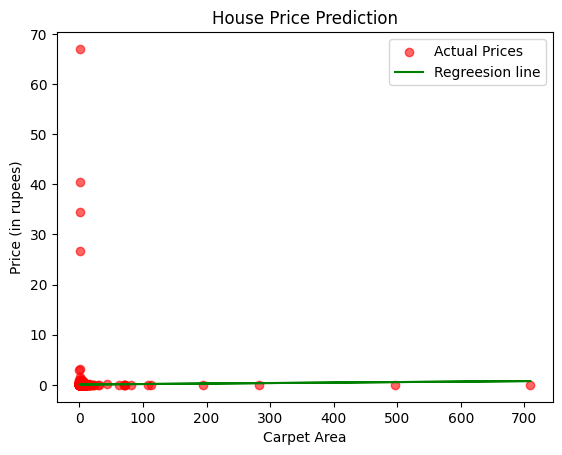

In [51]:

y_pred=w*x+b
plt.scatter(x,y,color="red",alpha=0.6, label="Actual Prices")
plt.plot(x,y_pred, color="green", label="Regreesion line")
plt.xlabel("Carpet Area")
plt.ylabel("Price (in rupees)")
plt.title("House Price Prediction")
plt.legend()
plt.show()


**Prediction**

In [60]:

carpet_area_sqft = 200.0# original input
carpet_area_scaled = carpet_area_sqft / 1000  # scaled for model

predicted_price = (w*carpet_area_scaled + b) * 100000

print(f"Predicted Price for house with {carpet_area_sqft} sqft = Rs. {predicted_price:.2f}")


Predicted Price for house with 200.0 sqft = Rs. 8115.53
